# 서브그룹 분석 — 연령대 · 금융이력별 C군 예측력 (XGBoost)

**검증 가설**

> 금융이력이 없고 나이가 적을수록 신규 비금융(C)의 영향이 클 것이다

M4 는 전체 표본에서 C군의 평균 기여를 본다. 그러나 C군의 가치는
집단에 따라 다를 수 있다. 특히 금융이력이 없는 씬파일러는 A군 정보가
부실하므로 대안정보의 실제 도입 목적과 직접 맞닿는다.

**분석 설계**

| 축 | 구분 |
|---|---|
| 연령대 | 20대 / 30대 / 40대 / 50대 / 60대+ |
| 금융이력 | 이력없음(씬파일러) / 이력있음 |
| 변수집합 | C군 전체 / 사회연결망 / 학력 / 차량 |

각 서브그룹 안에서 **C군만으로 모델을 적합**해 AUC 를 구한다.
`AUC − 0.5` 를 우연 대비 순수 예측력으로 본다.

**주의** — 서브그룹 AUC 는 전체 AUC 와 직접 비교하면 안 된다.
집단마다 연체율과 표본 크기가 달라 **그룹 간 상대 비교만 유효**하다.

**입력** — `model_A_financial_final.csv` / `model_B_nonfinancial_final.csv` /
`model_C_nonfinancial_new_final.csv`

**출력** — `C군_연령대별.csv` / `C군_씬파일러x연령대.csv` / `C군_변수별_lift.csv`

실행 시간은 Colab 기준 약 10분.

## 0. 설정

In [ ]:
!pip install xgboost -q

import os, warnings, gc
import numpy as np
import pandas as pd
from pandas.api.types import is_numeric_dtype
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive')

SRC = '/content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산'
OUT = f'{SRC}/서브그룹분석'
os.makedirs(OUT, exist_ok=True)

N_FOLDS = 5
RANDOM_STATE = 42
ID, TARGET = 'SK_ID_CURR', 'TARGET'

# 서브그룹은 표본이 작아 M1~M4 보다 가볍게 둔다
MIN_N, MIN_POS = 500, 50      # 이보다 작은 셀은 NaN 처리

print('xgboost', xgb.__version__, '| 출력 ->', OUT)

Mounted at /content/drive
xgboost 3.3.0 | 출력 -> /content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산/서브그룹분석


## 1. 데이터 준비

C군에 연령(B군)과 금융이력 플래그(A군)를 붙인다.
`BUREAU_NO_HISTORY_FLAG` 는 타 기관 신용거래 이력이 없는 씬파일러 표시다.

In [ ]:
A = pd.read_csv(f'{SRC}/model_A_financial_final.csv')
B = pd.read_csv(f'{SRC}/model_B_nonfinancial_final.csv')
C = pd.read_csv(f'{SRC}/model_C_nonfinancial_new_final.csv')

m = (B[[ID, TARGET, 'AGE']]
     .merge(C.drop(columns=[TARGET]), on=ID, how='inner')
     .merge(A[[ID, 'BUREAU_NO_HISTORY_FLAG']], on=ID, how='inner'))
del A, B, C; gc.collect()

for c in m.columns:
    if m[c].dtype == bool:
        m[c] = m[c].astype(int)

m['연령대'] = pd.cut(m['AGE'], [19, 29, 39, 49, 59, 100],
                   labels=['20대', '30대', '40대', '50대', '60대+'])
m['금융이력'] = np.where(m['BUREAU_NO_HISTORY_FLAG'] == 1, '이력없음', '이력있음')

EXCL = (ID, TARGET, 'AGE', '연령대', '금융이력', 'BUREAU_NO_HISTORY_FLAG')
C_ALL = [c for c in m.columns if c not in EXCL and is_numeric_dtype(m[c])]
SOC = [c for c in C_ALL if 'SOCIAL' in c]
EDU = [c for c in C_ALL if c.startswith('NAME_EDUCATION')]
HOU = [c for c in C_ALL if c.startswith('NAME_HOUSING')]
CAR = ['FLAG_OWN_CAR']

SETS = {'C전체': C_ALL, '사회연결망': SOC, '학력': EDU, '주거': HOU, '차량': CAR}

print(f'{len(m):,}명 | 전체 연체율 {m[TARGET].mean()*100:.2f}%')
for k, v in SETS.items():
    print(f'  {k:8s} {len(v):2d}개')

307,511명 | 전체 연체율 8.07%
  C전체      15개
  사회연결망     3개
  학력        5개
  주거        6개
  차량        1개


## 2. 서브그룹 AUC 함수

트리 모델이므로 원핫 기준범주를 제거할 필요가 없다.
C군 15개를 그대로 사용한다.

서브그룹은 표본이 작아 트리 수와 깊이를 M1~M4 보다 낮춘다.
같은 조건으로 모든 셀을 계산하므로 셀 간 비교는 유효하다.

In [ ]:
SUB_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    colsample_bytree=0.8,
    subsample=0.9,
    reg_lambda=1.0,
    min_child_weight=50,
    tree_method='hist',
    n_jobs=-1,
    verbosity=0,
    random_state=RANDOM_STATE,
)


def sub_auc(g, cols):
    """서브그룹 내 5-fold OOF AUC. 표본이 작으면 NaN."""
    y = g[TARGET].values
    if len(y) < MIN_N or y.sum() < MIN_POS:
        return np.nan

    X = g[cols].replace([np.inf, -np.inf], np.nan).astype('float32')
    spw = (y == 0).sum() / max((y == 1).sum(), 1)
    oof = np.zeros(len(y))

    for tr, va in StratifiedKFold(N_FOLDS, shuffle=True,
                                  random_state=RANDOM_STATE).split(X, y):
        mdl = xgb.XGBClassifier(**SUB_PARAMS, scale_pos_weight=spw)
        mdl.fit(X.iloc[tr], y[tr], verbose=False)
        oof[va] = mdl.predict_proba(X.iloc[va])[:, 1]
        del mdl; gc.collect()

    return round(roc_auc_score(y, oof), 4)

## 3. 연령대별 — 금융이력 무시

먼저 연령 축만 본다.

In [ ]:
rows = []
for age, g in m.groupby('연령대', observed=True):
    r = {'연령대': age, 'n': len(g), '연체율%': round(g[TARGET].mean()*100, 2)}
    for lab, cols in SETS.items():
        r[lab] = sub_auc(g, cols)
    rows.append(r)
    print(f'  {age} 완료', flush=True)

age_tbl = pd.DataFrame(rows)
for k in SETS:
    age_tbl[f'{k}_순수'] = (age_tbl[k] - 0.5).round(4)

print()
print('■ 연령대별 C군 단독 AUC')
display(age_tbl[['연령대', 'n', '연체율%'] + list(SETS)].style.hide(axis='index')
        .background_gradient(subset=['C전체'], cmap='Oranges')
        .format({k: '{:.4f}' for k in SETS}))

print('■ 우연 대비 순수 예측력 (AUC - 0.5)')
display(age_tbl[['연령대'] + [f'{k}_순수' for k in SETS]].style.hide(axis='index')
        .background_gradient(cmap='RdYlGn', axis=None,
                             subset=[f'{k}_순수' for k in SETS])
        .format({f'{k}_순수': '{:+.4f}' for k in SETS}))

  20대 완료
  30대 완료
  40대 완료
  50대 완료
  60대+ 완료

■ 연령대별 C군 단독 AUC


연령대,n,연체율%,C전체,사회연결망,학력,주거,차량
20대,37541,11.500000,0.6018,0.5256,0.5844,0.5003,0.5223
30대,81267,9.870000,0.6005,0.5235,0.5744,0.5160,0.5369
40대,78669,7.740000,0.5769,0.5230,0.5476,0.5064,0.5297
50대,68070,6.290000,0.5336,0.5158,0.5220,0.5058,0.5078
60대+,41964,5.030000,0.5332,0.5185,0.5239,0.5020,0.4871


■ 우연 대비 순수 예측력 (AUC - 0.5)


연령대,C전체_순수,사회연결망_순수,학력_순수,주거_순수,차량_순수
20대,+0.1018,+0.0256,+0.0844,+0.0003,+0.0223
30대,+0.1005,+0.0235,+0.0744,+0.0160,+0.0369
40대,+0.0769,+0.0230,+0.0476,+0.0064,+0.0297
50대,+0.0336,+0.0158,+0.0220,+0.0058,+0.0078
60대+,+0.0332,+0.0185,+0.0239,+0.0020,-0.0129


## 4. 금융이력 × 연령대 교차

가설의 두 축을 함께 본다.

In [ ]:
print('■ 씬파일러 x 연령대 분포')
dist = (m.groupby(['금융이력', '연령대'], observed=True)
          .agg(n=(TARGET, 'size'), 연체율=(TARGET, 'mean')))
dist['연체율%'] = (dist['연체율'] * 100).round(2)
display(dist[['n', '연체율%']])

■ 씬파일러 x 연령대 분포


n   연체율%
금융이력 연령대               
이력없음 20대    7886  12.91
     30대   10836  12.62
     40대    9904   9.46
     50대    9292   8.05
     60대+   6102   6.33
이력있음 20대   29655  11.13
     30대   70431   9.45
     40대   68765   7.50
     50대   58778   6.01
     60대+  35862   4.81

In [ ]:
rows = []
for (s, age), g in m.groupby(['금융이력', '연령대'], observed=True):
    r = {'금융이력': s, '연령대': age, 'n': len(g),
         '연체율%': round(g[TARGET].mean()*100, 2)}
    for lab in ['C전체', '사회연결망', '학력']:
        r[lab] = sub_auc(g, SETS[lab])
    rows.append(r)
    print(f'  {s} {age} 완료', flush=True)

cross = pd.DataFrame(rows)
for k in ['C전체', '사회연결망', '학력']:
    cross[f'{k}_순수'] = (cross[k] - 0.5).round(4)

print()
display(cross.style.hide(axis='index')
        .format({k: '{:.4f}' for k in ['C전체', '사회연결망', '학력']}, na_rep='-'))

  이력없음 20대 완료
  이력없음 30대 완료
  이력없음 40대 완료
  이력없음 50대 완료
  이력없음 60대+ 완료
  이력있음 20대 완료
  이력있음 30대 완료
  이력있음 40대 완료
  이력있음 50대 완료
  이력있음 60대+ 완료



금융이력,연령대,n,연체율%,C전체,사회연결망,학력,C전체_순수,사회연결망_순수,학력_순수
이력없음,20대,7886,12.910000,0.5849,0.5232,0.5770,0.084900,0.023200,0.077000
이력없음,30대,10836,12.620000,0.5806,0.5039,0.5578,0.080600,0.003900,0.057800
이력없음,40대,9904,9.460000,0.5769,0.5294,0.5375,0.076900,0.029400,0.037500
이력없음,50대,9292,8.050000,0.5455,0.5087,0.5280,0.045500,0.008700,0.028000
이력없음,60대+,6102,6.330000,0.5051,0.5174,0.5184,0.005100,0.017400,0.018400
이력있음,20대,29655,11.130000,0.5943,0.5184,0.5844,0.094300,0.018400,0.084400
이력있음,30대,70431,9.450000,0.5983,0.5204,0.5716,0.098300,0.020400,0.071600
이력있음,40대,68765,7.500000,0.5739,0.5231,0.5455,0.073900,0.023100,0.045500
이력있음,50대,58778,6.010000,0.5302,0.5135,0.5207,0.030200,0.013500,0.020700
이력있음,60대+,35862,4.810000,0.5319,0.5186,0.5219,0.031900,0.018600,0.021900


In [ ]:
for k in ['C전체', '사회연결망', '학력']:
    p = cross.pivot(index='연령대', columns='금융이력', values=f'{k}_순수')
    p['차이(없음-있음)'] = (p['이력없음'] - p['이력있음']).round(4)
    print(f'■ {k} — 순수 예측력 (AUC-0.5)')
    display(p.style.background_gradient(cmap='RdYlGn', axis=None,
                                        subset=['이력없음', '이력있음'])
            .format('{:+.4f}', na_rep='-'))

■ C전체 — 순수 예측력 (AUC-0.5)


금융이력,이력없음,이력있음,차이(없음-있음)
연령대,,,
20대,+0.0849,+0.0943,-0.0094
30대,+0.0806,+0.0983,-0.0177
40대,+0.0769,+0.0739,+0.0030
50대,+0.0455,+0.0302,+0.0153
60대+,+0.0051,+0.0319,-0.0268


■ 사회연결망 — 순수 예측력 (AUC-0.5)


금융이력,이력없음,이력있음,차이(없음-있음)
연령대,,,
20대,+0.0232,+0.0184,+0.0048
30대,+0.0039,+0.0204,-0.0165
40대,+0.0294,+0.0231,+0.0063
50대,+0.0087,+0.0135,-0.0048
60대+,+0.0174,+0.0186,-0.0012


■ 학력 — 순수 예측력 (AUC-0.5)


금융이력,이력없음,이력있음,차이(없음-있음)
연령대,,,
20대,+0.0770,+0.0844,-0.0074
30대,+0.0578,+0.0716,-0.0138
40대,+0.0375,+0.0455,-0.0080
50대,+0.0280,+0.0207,+0.0073
60대+,+0.0184,+0.0219,-0.0035


## 5. C군 변수별 lift — 연령대 교차

모델이 아니라 단순 연체율 비로 본다.
연속형(사회연결망 2개)은 0 초과 여부로 이분한다.

In [ ]:
CONT = {'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE'}

rows = []
for c in C_ALL:
    b = (m[c] > 0).astype(int) if c in CONT else m[c].astype(int)
    for age, g in m.groupby('연령대', observed=True):
        bb = b[g.index]
        if bb.sum() < 30 or (bb == 0).sum() < 30:
            rows.append({'변수': c, '연령대': age, 'lift': np.nan,
                         'n1': int(bb.sum())})
            continue
        r1 = g[TARGET][bb == 1].mean()
        r0 = g[TARGET][bb == 0].mean()
        rows.append({'변수': c, '연령대': age, 'lift': round(r1 / r0, 3),
                     'n1': int(bb.sum())})

lift = pd.DataFrame(rows)
piv = lift.pivot(index='변수', columns='연령대', values='lift')
piv['20대-60대'] = (piv['20대'] - piv['60대+']).round(3)


def short(s):
    return (s.replace('NAME_EDUCATION_TYPE_C_', 'EDU_')
             .replace('NAME_HOUSING_TYPE_C_', 'HOU_')
             .replace('_CNT_SOCIAL_CIRCLE', '')
             .replace('SOCIAL_CIRCLE_MISSING_FLAG', 'SOC_MISS'))


piv.index = [short(i) for i in piv.index]
piv = piv.sort_values('20대-60대', key=abs, ascending=False)

print('■ C군 변수별 lift (1 vs 0 연체율 비) — 연령대 교차')
print('  lift > 1 이면 해당 값일 때 위험 증가')
display(piv.style.background_gradient(cmap='RdYlGn_r', axis=None,
                                      subset=['20대', '30대', '40대', '50대', '60대+'])
        .format('{:.3f}', na_rep='-'))

■ C군 변수별 lift (1 vs 0 연체율 비) — 연령대 교차
  lift > 1 이면 해당 값일 때 위험 증가


연령대,20대,30대,40대,50대,60대+,20대-60대
EDU_Secondary / secondary special,1.891,1.818,1.581,1.321,1.269,0.622
HOU_Office apartment,0.814,0.674,0.800,0.731,1.359,-0.545
HOU_Rented apartment,1.106,1.359,1.492,1.645,1.531,-0.425
SOC_MISS,0.459,0.410,0.389,0.331,0.801,-0.342
HOU_Co-op apartment,1.148,0.774,0.674,0.860,0.924,0.224
HOU_Municipal apartment,0.969,1.164,1.028,1.148,1.188,-0.219
EDU_Higher education,0.487,0.498,0.586,0.723,0.698,-0.211
HOU_With parents,1.045,1.247,1.381,1.572,0.871,0.174
FLAG_OWN_CAR,0.801,0.735,0.777,0.921,0.956,-0.155
EDU_Lower secondary,1.455,1.535,1.750,1.312,1.320,0.135


## 6. 시각화

축 라벨은 한글 폰트 설치 없이 렌더되도록 영문으로 둔다.

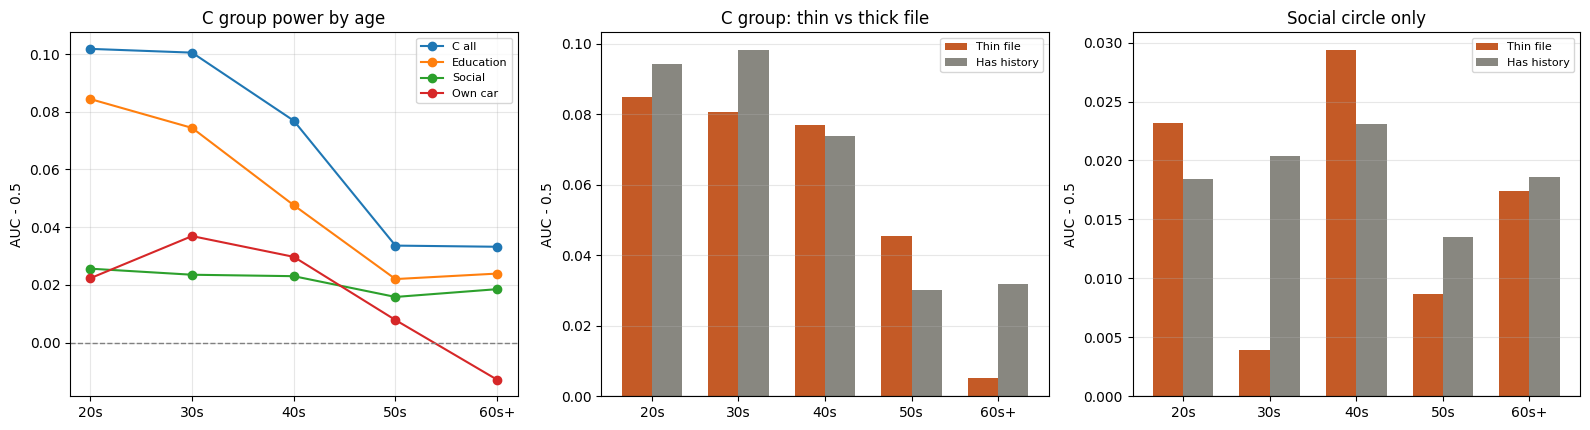

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))
ages = ['20s', '30s', '40s', '50s', '60s+']

# (1) 연령대별 C군 구성요소
for lab, en in [('C전체', 'C all'), ('학력', 'Education'),
                ('사회연결망', 'Social'), ('차량', 'Own car')]:
    ax[0].plot(range(5), age_tbl[f'{lab}_순수'], marker='o', label=en)
ax[0].axhline(0, ls='--', c='gray', lw=1)
ax[0].set_xticks(range(5)); ax[0].set_xticklabels(ages)
ax[0].set_ylabel('AUC - 0.5'); ax[0].set_title('C group power by age')
ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)

x = np.arange(5); w = 0.35

# (2) C전체 — 씬파일러 비교
p1 = cross.pivot(index='연령대', columns='금융이력', values='C전체_순수')
ax[1].bar(x - w/2, p1['이력없음'], w, label='Thin file', color='#C45A26')
ax[1].bar(x + w/2, p1['이력있음'], w, label='Has history', color='#888780')
ax[1].axhline(0, c='black', lw=.8)
ax[1].set_xticks(x); ax[1].set_xticklabels(ages)
ax[1].set_ylabel('AUC - 0.5'); ax[1].set_title('C group: thin vs thick file')
ax[1].legend(fontsize=8); ax[1].grid(axis='y', alpha=.3)

# (3) 사회연결망 — 씬파일러 비교
p2 = cross.pivot(index='연령대', columns='금융이력', values='사회연결망_순수')
ax[2].bar(x - w/2, p2['이력없음'], w, label='Thin file', color='#C45A26')
ax[2].bar(x + w/2, p2['이력있음'], w, label='Has history', color='#888780')
ax[2].axhline(0, c='black', lw=.8)
ax[2].set_xticks(x); ax[2].set_xticklabels(ages)
ax[2].set_ylabel('AUC - 0.5'); ax[2].set_title('Social circle only')
ax[2].legend(fontsize=8); ax[2].grid(axis='y', alpha=.3)

plt.tight_layout(); plt.show()

## 7. 최종 결과

In [ ]:
best = cross.loc[cross['사회연결망_순수'].idxmax()]
pc = cross.pivot(index='연령대', columns='금융이력', values='C전체_순수')
ps = cross.pivot(index='연령대', columns='금융이력', values='사회연결망_순수')

young, old = age_tbl.iloc[0], age_tbl.iloc[-1]

lines = [
    '=' * 64,
    '서브그룹 분석 — 연령대 · 금융이력별 C군 예측력',
    '=' * 64,
    '',
    '■ 가설  금융이력이 없고 나이가 적을수록 C군의 영향이 클 것이다',
    '',
    '■ 축 1 — 연령  (순수 예측력 = AUC - 0.5)',
    f'   C전체     20대 {young["C전체_순수"]:+.4f}  ->  60대+ {old["C전체_순수"]:+.4f}',
    f'   학력      20대 {young["학력_순수"]:+.4f}  ->  60대+ {old["학력_순수"]:+.4f}',
    f'   사회연결망  20대 {young["사회연결망_순수"]:+.4f}  ->  60대+ {old["사회연결망_순수"]:+.4f}',
    '',
    '■ 축 2 — 금융이력  (이력없음 - 이력있음)',
] + [f'   {k:8s} ' + '  '.join(
        f'{a}:{(cross.pivot(index="연령대", columns="금융이력", values=f"{k}_순수").loc[a, "이력없음"] - cross.pivot(index="연령대", columns="금융이력", values=f"{k}_순수").loc[a, "이력있음"]):+.4f}'
        for a in ['20대', '30대', '40대', '50대', '60대+'])
     for k in ['C전체', '사회연결망']] + [
    '',
    '■ 두 축이 겹치는 지점',
    f'   사회연결망 최고 셀: {best["금융이력"]} x {best["연령대"]}  '
    f'순수 예측력 {best["사회연결망_순수"]:+.4f}  (n={best["n"]:,})',
    '',
    '■ 해석 주의',
    '   · 서브그룹 AUC 는 전체 AUC 와 직접 비교하면 안 된다',
    '     집단마다 연체율과 표본이 달라 그룹 간 상대 비교만 유효하다',
    '   · 표본이 작은 셀은 변동이 크다. random_state 를 바꿔 재현성을 확인할 것',
    '   · C전체의 주 동력이 무엇인지 확인해야 한다',
    '     학력이 대부분을 차지하면 "C군" 이 아니라 "학력" 의 효과다',
    '=' * 64,
]
print('\n'.join(lines))

서브그룹 분석 — 연령대 · 금융이력별 C군 예측력

■ 가설  금융이력이 없고 나이가 적을수록 C군의 영향이 클 것이다

■ 축 1 — 연령  (순수 예측력 = AUC - 0.5)
   C전체     20대 +0.1018  ->  60대+ +0.0332
   학력      20대 +0.0844  ->  60대+ +0.0239
   사회연결망  20대 +0.0256  ->  60대+ +0.0185

■ 축 2 — 금융이력  (이력없음 - 이력있음)
   C전체      20대:-0.0094  30대:-0.0177  40대:+0.0030  50대:+0.0153  60대+:-0.0268
   사회연결망    20대:+0.0048  30대:-0.0165  40대:+0.0063  50대:-0.0048  60대+:-0.0012

■ 두 축이 겹치는 지점
   사회연결망 최고 셀: 이력없음 x 40대  순수 예측력 +0.0294  (n=9,904)

■ 해석 주의
   · 서브그룹 AUC 는 전체 AUC 와 직접 비교하면 안 된다
     집단마다 연체율과 표본이 달라 그룹 간 상대 비교만 유효하다
   · 표본이 작은 셀은 변동이 크다. random_state 를 바꿔 재현성을 확인할 것
   · C전체의 주 동력이 무엇인지 확인해야 한다
     학력이 대부분을 차지하면 "C군" 이 아니라 "학력" 의 효과다


## 8. CSV 저장

In [ ]:
age_tbl.to_csv(f'{OUT}/C군_연령대별.csv', index=False, encoding='utf-8-sig')
cross.to_csv(f'{OUT}/C군_씬파일러x연령대.csv', index=False, encoding='utf-8-sig')
piv.rename_axis('변수').to_csv(f'{OUT}/C군_변수별_lift.csv', encoding='utf-8-sig')

print(f'저장 완료 -> {OUT}')
for f_, d_ in [('C군_연령대별.csv', age_tbl),
               ('C군_씬파일러x연령대.csv', cross),
               ('C군_변수별_lift.csv', piv)]:
    print(f'  {f_:28s} {d_.shape[0]:2d}행 x {d_.shape[1]}열')

저장 완료 -> /content/drive/MyDrive/BOOSTMAP/데이터/완료/재계산/서브그룹분석
  C군_연령대별.csv                   5행 x 13열
  C군_씬파일러x연령대.csv              10행 x 10열
  C군_변수별_lift.csv              15행 x 6열


### 재현성 확인 (선택)

표본이 작은 셀은 fold 분할에 따라 값이 흔들릴 수 있다.
`random_state` 를 바꿔 같은 방향이 나오는지 확인한다.

```python
for seed in [1, 7, 2024]:
    RANDOM_STATE = seed
    g = m[(m['금융이력'] == '이력없음') & (m['연령대'] == '20대')]
    print(seed, sub_auc(g, SETS['사회연결망']))
```

### 해석 시 유의사항

**서브그룹 AUC 의 성격**

각 집단 안에서 C군만으로 연체를 예측한 결과다.
집단 간 연체율 차이는 반영되지 않으므로,
"어느 집단이 위험한가" 가 아니라 **"어느 집단에서 C군이 잘 작동하는가"** 를 답한다.

**C전체와 하위그룹의 관계**

C전체 예측력이 높아도 그 대부분이 학력에서 나온다면,
결론은 "C군이 유효하다" 가 아니라 "학력이 유효하다" 가 되어야 한다.
3절 출력에서 `C전체_순수` 와 `학력_순수` 를 비교해 확인한다.

**표본 크기**

씬파일러 × 20대 조합이 가장 작다. 이 셀의 값은 다른 셀보다
변동이 크므로 위의 재현성 확인을 함께 보고하는 것이 안전하다.